In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7398.95it/s]


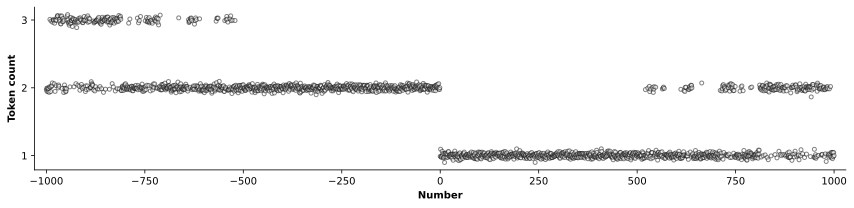

In [3]:
from transformers import AutoTokenizer, AutoModel

model = AutoModel.from_pretrained('gpt2')
tokenizer = AutoTokenizer.from_pretrained('gpt2')

embeddings = model.wte.weight.detach()

numbers = np.arange(-1000, 1001)
num_tokens = np.zeros(len(numbers), dtype=int)
token_idx = []
for i in range(len(numbers)):
    t = tokenizer.encode(str(numbers[i]))

    token_idx.append(t)
    num_tokens[i] = len(t)

plt.figure(figsize=(12,3))
plt.plot(numbers,num_tokens+np.random.normal(0,.03,len(numbers)),'ko',markerfacecolor='w',markersize=4,alpha=.5)
plt.gca().set(xlabel='Number',ylabel='Token count',yticks=np.unique(num_tokens), xlim=[numbers[0]-30,numbers[-1]+30])

plt.tight_layout()
plt.savefig('ch3_proj10_part1a.png')
plt.show()

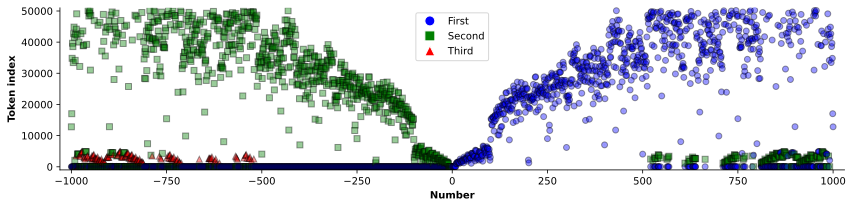

In [4]:
plt.figure(figsize=(12,3))
colord = 'bgr'
shape = 'os^'

for i in range(len(numbers)):
    t = token_idx[i]
    for ti in range(len(t)):
       plt.plot(numbers[i],t[ti],'k',marker=shape[ti],markerfacecolor=colord[ti], markersize=6,alpha=.4,linewidth=.4)

for i in range(3):
  plt.plot(0,0,'w',marker=shape[i],markerfacecolor=colord[i], markersize=10,alpha=0,linewidth=.5,label=['First','Second','Third'][i])

  h = plt.legend()
  for e in h.legend_handles: e.set_alpha(1)

plt.gca().set(xlabel='Number',ylabel='Token index',ylim=[-1000,51000],xlim=[numbers[0]-30,numbers[-1]+30])

plt.tight_layout()
plt.savefig('ch3_proj10_part1b.png')
plt.show()

In [5]:
matches_count = np.zeros(1000)
matches_vals = np.zeros(1000)

for i in range(1000):
    n = f'({numbers[i]:>5},{numbers[-i-1]:>4})'
    t = f'({num_tokens[i]-1},{num_tokens[-i-1]})'

    matches_count[i] = (num_tokens[i]-1) == num_tokens[-i-1]
    matches_vals[i] = token_idx[i][1:] == token_idx[-i-1]

matches_count.sum(), matches_vals.sum()

(np.float64(1000.0), np.float64(1000.0))

In [6]:
for i in range(11):
  print(f'The token(s) for "{i}" are: {tokenizer.encode(str(i))}')  

The token(s) for "0" are: [15]
The token(s) for "1" are: [16]
The token(s) for "2" are: [17]
The token(s) for "3" are: [18]
The token(s) for "4" are: [19]
The token(s) for "5" are: [20]
The token(s) for "6" are: [21]
The token(s) for "7" are: [22]
The token(s) for "8" are: [23]
The token(s) for "9" are: [24]
The token(s) for "10" are: [940]


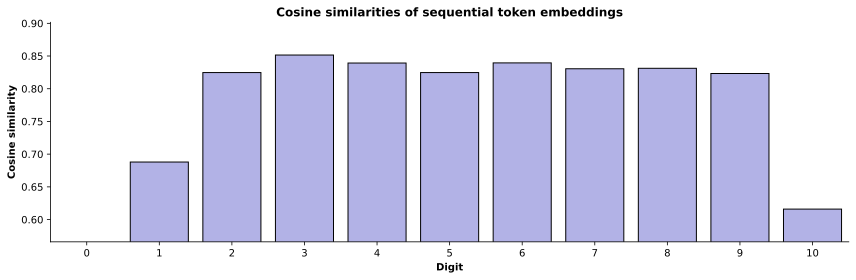

In [7]:
tokens = [tokenizer.encode(str(i))[0] for i in range(11)]

cossim = np.full(len(tokens), np.nan)

for ti in range(1, len(tokens)):
    v1 = embeddings[tokens[ti], :]
    v2 = embeddings[tokens[ti-1], :]
    cossim[ti] = torch.sum(v1*v2) / torch.sqrt(torch.sum(v1**2)*torch.sum(v2**2))

plt.figure(figsize=(12,4))
plt.bar(np.arange(len(cossim)),cossim,facecolor=[.7,.7,.9],edgecolor='k')
plt.gca().set(xticks=range(len(tokens)),xticklabels=[tokenizer.decode(t) for t in tokens], xlabel='Digit',ylabel='Cosine similarity', xlim=[-.5,len(tokens)-.5],ylim=[np.nanmin(cossim)-.05,np.nanmax(cossim)+.05])

plt.title('Cosine similarities of sequential token embeddings',fontweight='bold')

plt.tight_layout()
plt.savefig('ch3_proj10_part3.png')
plt.show() 

In [8]:
nums = [str(i) for i in range(10)] + [str(i*10) for i in range(1, 11)]
tokens = tokenizer.encode(nums)
tokens = [t[0] for t in tokens]

for t in tokens:
  print(f'{t:5} is "{tokenizer.decode(t)}"') 

   15 is "0"
   16 is "1"
   17 is "2"
   18 is "3"
   19 is "4"
   20 is "5"
   21 is "6"
   22 is "7"
   23 is "8"
   24 is "9"
  940 is "10"
 1238 is "20"
 1270 is "30"
 1821 is "40"
 1120 is "50"
 1899 is "60"
 2154 is "70"
 1795 is "80"
 3829 is "90"
 3064 is "100"


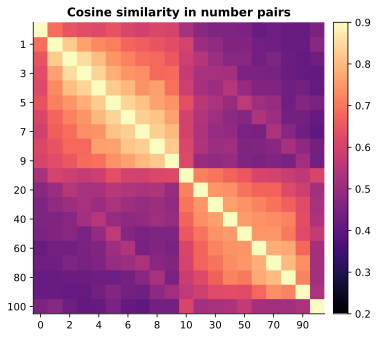

In [9]:
E = embeddings[tokens,:]
E_norm = F.normalize(E,p=2,dim=1)
csM = E_norm @ E_norm.T

plt.imshow(csM,vmin=.2,vmax=.9,cmap='magma')
plt.gca().set(xticks=range(0,len(nums),2),xticklabels=nums[::2], yticks=range(1,len(nums),2),yticklabels=nums[1::2], title='Cosine similarity in number pairs')
plt.colorbar(pad=.02)

plt.tight_layout()
plt.savefig('ch3_proj10_part4.png')
plt.show()